#Segmentação de Clientes

In [5]:
# -----------------------------------------------------------------
# CÉLULA 1: FAÇA O UPLOAD DOS SEUS DADOS AQUI
# -----------------------------------------------------------------
# Instrução: Execute esta célula e selecione o arquivo 'clientes.csv'

from google.colab import files
import io
import pandas as pd

print("Por favor, faça o upload do arquivo 'clientes.csv'...")
uploaded = files.upload()

# Verifica se o arquivo foi carregado
if 'clientes.csv' in uploaded:
    print("\nArquivo 'clientes.csv' carregado com sucesso!")
    # Carrega os dados em um DataFrame
    try:
        data = pd.read_csv(io.BytesIO(uploaded['clientes.csv']))
    except Exception as e:
        print(f"Erro ao ler o csv: {e}")
else:
    print("\nArquivo 'clientes.csv' não encontrado. Tente executar a célula novamente.")

Por favor, faça o upload do arquivo 'clientes.csv'...


Saving clientes.csv to clientes.csv

Arquivo 'clientes.csv' carregado com sucesso!


Digite a qtd de grupos que deseja encontrar (min 3):5
Análise de Cluster com K = 5


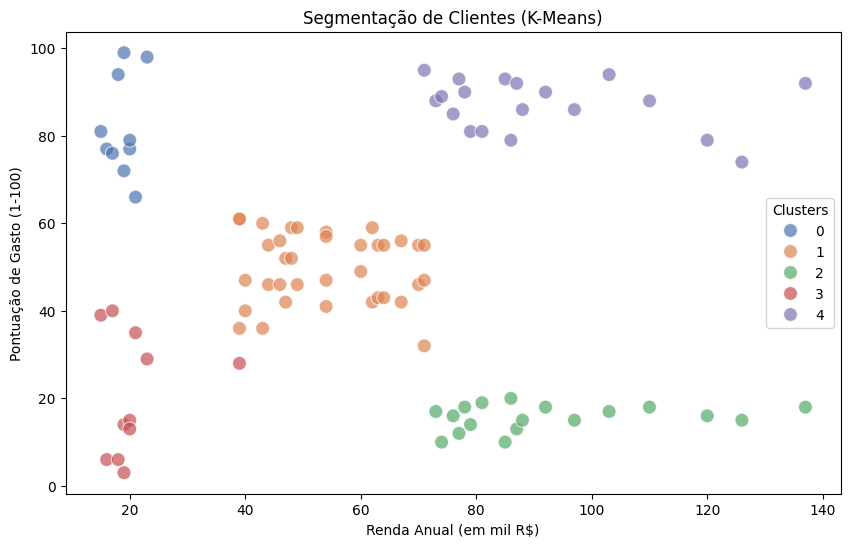

In [6]:
# -----------------------------------------------------------------
# CÉLULA 2: EXECUTE A ANÁLISE DE CLUSTER
# -----------------------------------------------------------------
# Instrução: Defina o número de clusters (K) e execute a célula.

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns # Usado para gráficos mais bonitos

# --- CONFIGURAÇÃO (O aluno só mexe aqui) ---
try:
  Ks = int(input("Digite a qtd de grupos que deseja encontrar (min 3):"))
except ValueError:
  print(f"Digite um valor inteiro")
except Exception as e:
  print(f"Erro ao ler o input: {e}")

if type(Ks) == int and type(Ks) != str and Ks > 0:
  K_CLUSTERS = Ks # Defina o número de grupos que você quer encontrar
  # ------------------------------------------

  if 'data' in locals():
      # Selecionando as colunas para a análise
      # (Usando os nomes exatos do nosso CSV)
      features = data[['Renda Anual (em mil R$)', 'Pontuação de Gasto (1-100)']]

      # Criando e treinando o modelo K-Means
      kmeans = KMeans(n_clusters=K_CLUSTERS, random_state=42, n_init=10)
      data['Cluster'] = kmeans.fit_predict(features)

      # --- Exibindo o Gráfico ---
      print(f"Análise de Cluster com K = {K_CLUSTERS}")

      plt.figure(figsize=(10, 6))
      sns.scatterplot(
          data=data,
          x='Renda Anual (em mil R$)',
          y='Pontuação de Gasto (1-100)',
          hue='Cluster',       # Colore os pontos pelo cluster
          palette='deep',      # Paleta de cores
          s=100,               # Tamanho dos pontos
          alpha=0.7
      )
      plt.title('Segmentação de Clientes (K-Means)')
      plt.legend(title='Clusters')
      plt.show()

  else:
      print("Erro: Os dados não foram carregados. Execute a Célula 1 primeiro.")
else:
  print("Erro: Entrada de Ks invalida. Execute a Célula 2 novamente.")